ORIGINAL DATASET
    Student_ID   Age  Study_Hours  Attendance  Assignments  Final_Score
0            1  18.0          5.0        85.0          8.0         72.0
1            2  19.0          7.0        90.0          9.0         85.0
2            3  18.0          4.0        78.0          7.0         68.0
3            4  20.0          8.0        95.0         10.0         92.0
4            5  19.0          NaN        88.0          8.0         80.0
5            6  18.0          6.0         NaN          9.0         78.0
6            7   NaN          3.0        70.0          6.0         60.0
7            8  21.0          9.0        96.0         10.0         95.0
8            9  19.0          5.0        82.0          NaN          NaN
9           10  20.0          7.0        91.0          9.0         88.0
10          11  18.0          4.0        76.0          7.0         65.0
11          12  19.0          6.0        89.0          8.0         79.0
12          13  20.0          8.0        94.0  

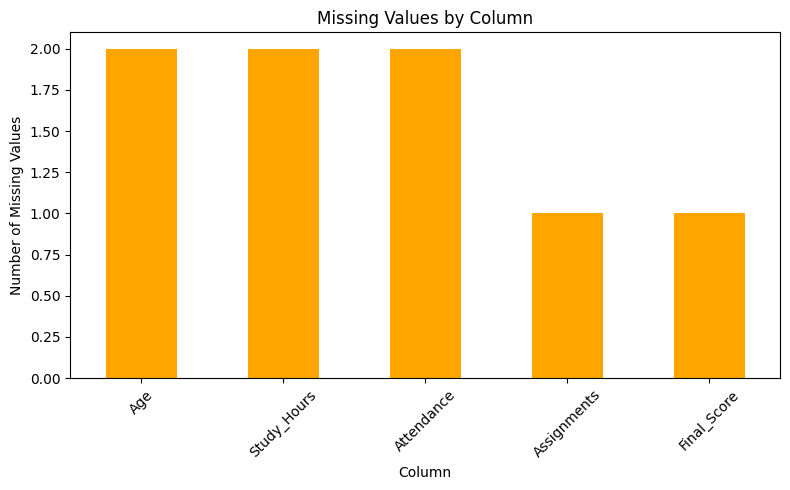


MISSING VALUES AFTER CLEANING
Student_ID     0
Age            0
Study_Hours    0
Attendance     0
Assignments    0
Final_Score    0
dtype: int64

SUMMARY STATISTICS
       Student_ID        Age  Study_Hours  Attendance  Assignments  \
count    20.00000  20.000000     20.00000   20.000000    20.000000   
mean     10.50000  19.250000      6.25000   86.900000     8.400000   
std       5.91608   1.019546      1.88833    8.076281     1.353358   
min       1.00000  18.000000      3.00000   70.000000     6.000000   
25%       5.75000  18.750000      5.00000   81.500000     7.000000   
50%      10.50000  19.000000      6.00000   88.500000     9.000000   
75%      15.25000  20.000000      7.25000   92.500000     9.250000   
max      20.00000  21.000000     10.00000   98.000000    10.000000   

       Final_Score  
count    20.000000  
mean     79.750000  
std      11.465624  
min      60.000000  
25%      69.750000  
50%      80.000000  
75%      88.750000  
max      97.000000  

NUMPY STATIST

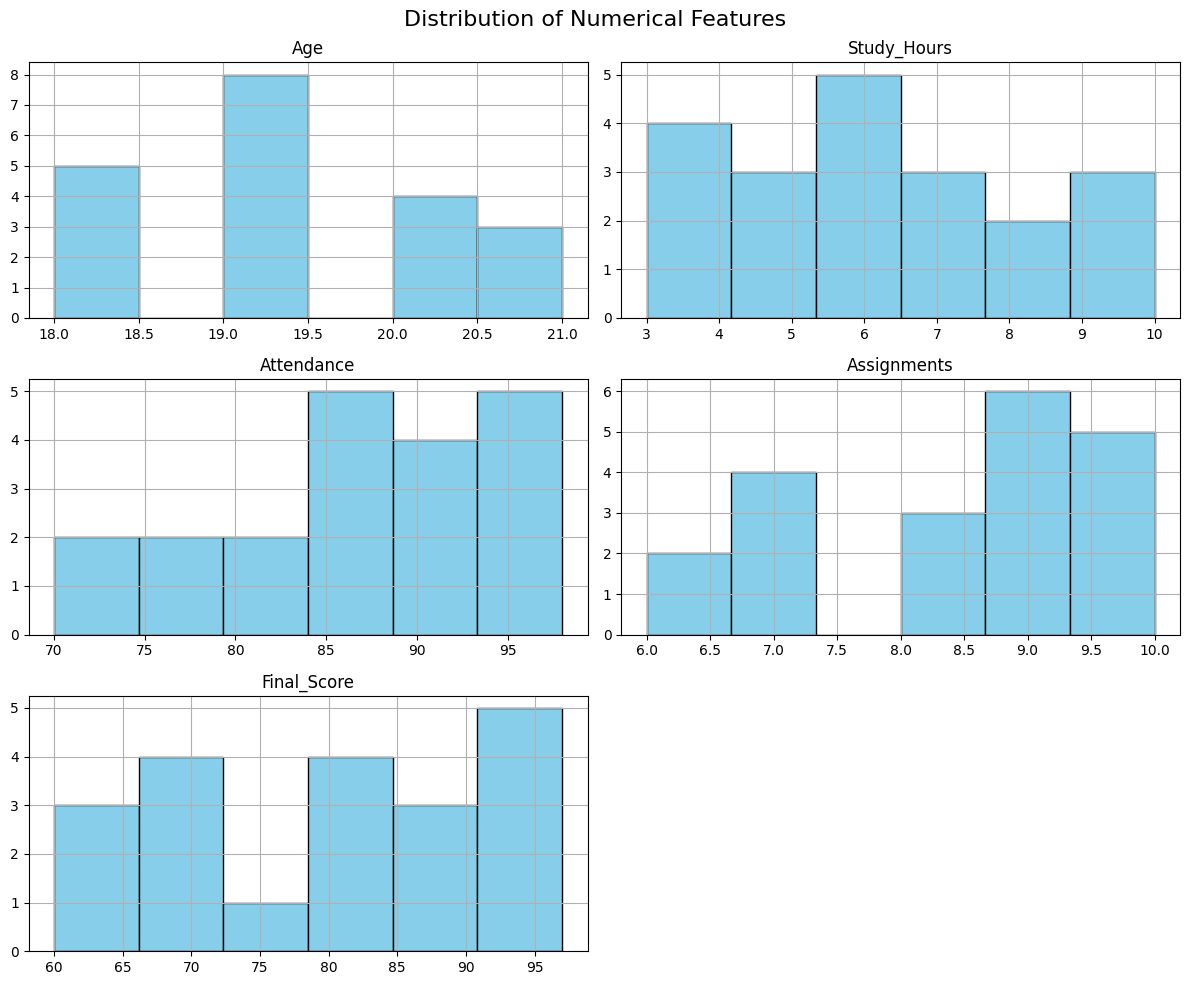

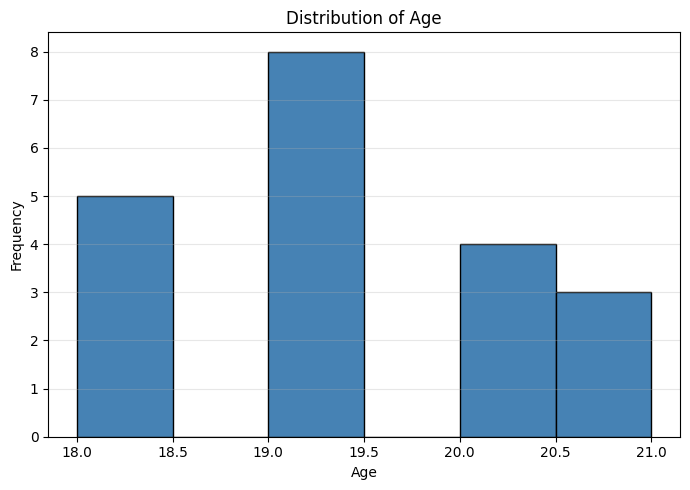

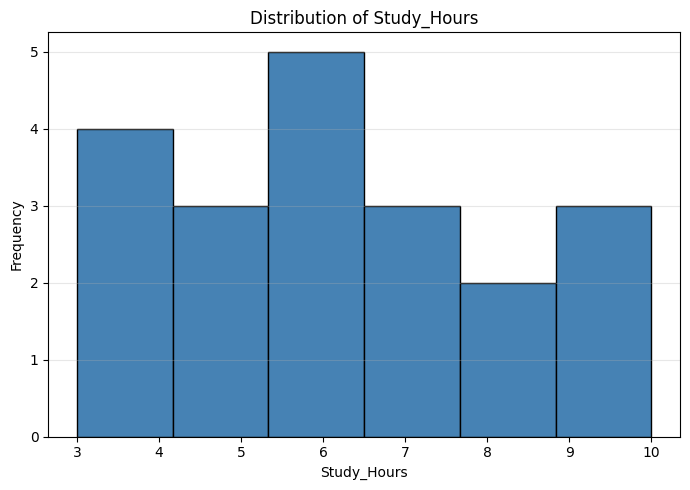

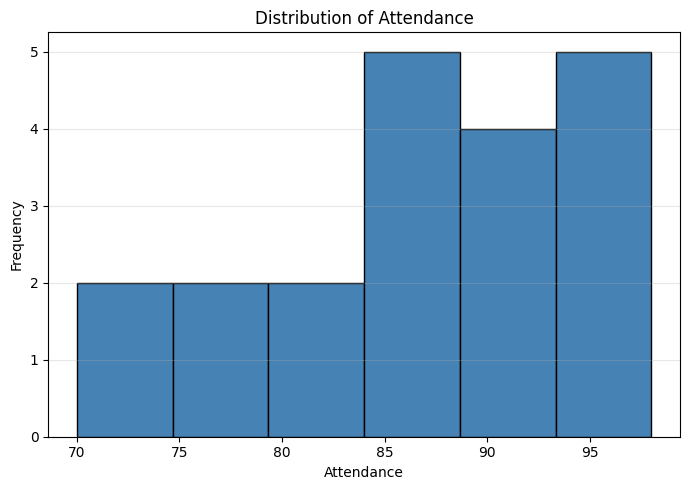

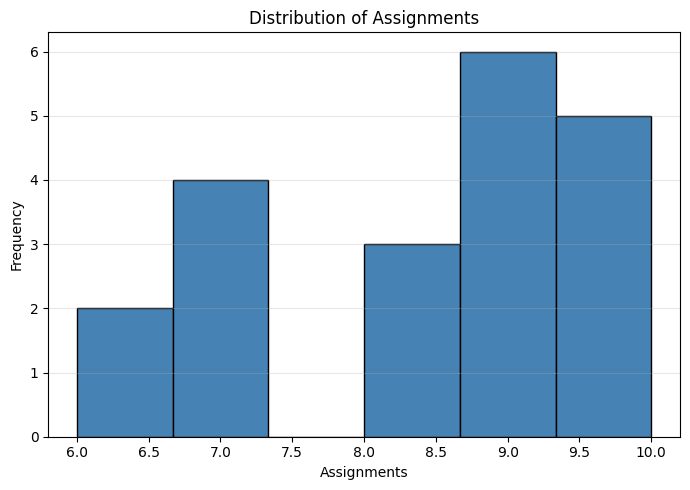

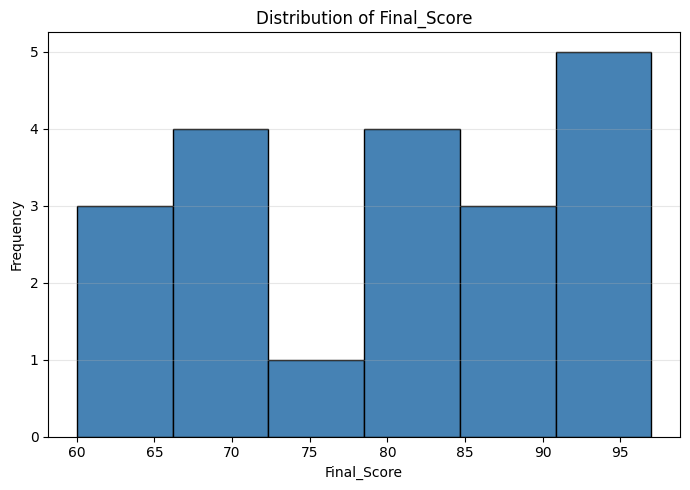

/tmp/ipykernel_2368/2519075667.py:285: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


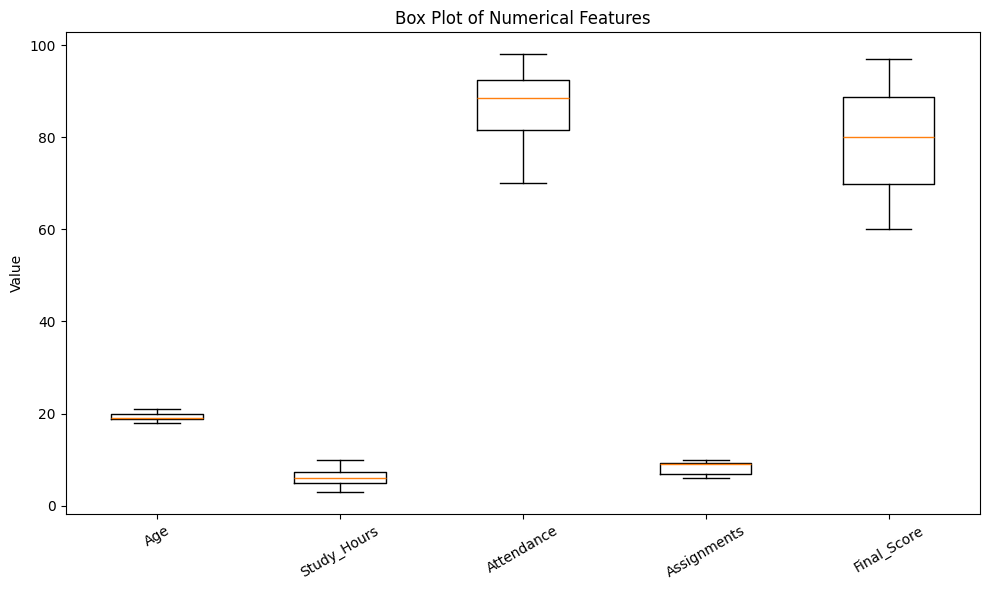


CORRELATION MATRIX
                  Age  Study_Hours  Attendance  Assignments  Final_Score
Age          1.000000     0.785959    0.760633     0.724737     0.834066
Study_Hours  0.785959     1.000000    0.829989     0.844383     0.907341
Attendance   0.760633     0.829989    1.000000     0.899496     0.932708
Assignments  0.724737     0.844383    0.899496     1.000000     0.966676
Final_Score  0.834066     0.907341    0.932708     0.966676     1.000000


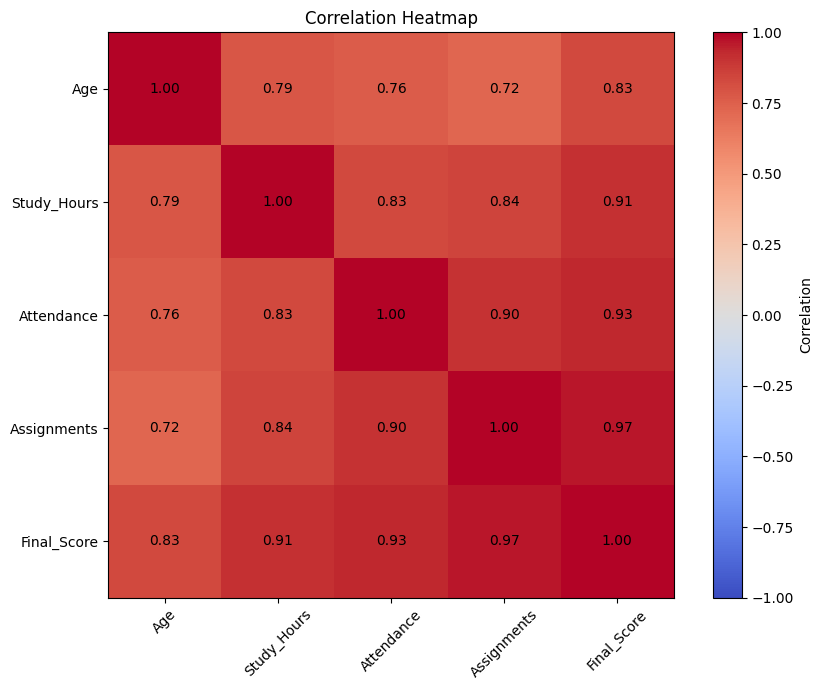

In [3]:
# ============================================================
# EXPERIMENT:
# Data Loading, Cleaning and Exploratory Data Analysis (EDA)
#
# Libraries:
# NumPy
# Pandas
# Matplotlib
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE / LOAD DATASET
# ============================================================
# In a real experiment, replace this with:
#
# df = pd.read_csv("student_data.csv")
#
# Here we create a sample dataset so the program can run
# without requiring an external file.

data = {
    "Student_ID": np.arange(1, 21),

    "Age": [
        18, 19, 18, 20, 19,
        18, np.nan, 21, 19, 20,
        18, 19, 20, np.nan, 21,
        19, 18, 20, 19, 21
    ],

    "Study_Hours": [
        5, 7, 4, 8, np.nan,
        6, 3, 9, 5, 7,
        4, 6, 8, 5, 10,
        7, np.nan, 6, 4, 9
    ],

    "Attendance": [
        85, 90, 78, 95, 88,
        np.nan, 70, 96, 82, 91,
        76, 89, 94, 80, 98,
        87, 73, 92, np.nan, 97
    ],

    "Assignments": [
        8, 9, 7, 10, 8,
        9, 6, 10, np.nan, 9,
        7, 8, 10, 7, 10,
        9, 6, 9, 7, 10
    ],

    "Final_Score": [
        72, 85, 68, 92, 80,
        78, 60, 95, np.nan, 88,
        65, 79, 91, 70, 97,
        84, 62, 86, 69, 94
    ]
}

df = pd.DataFrame(data)


# ============================================================
# 2. DISPLAY ORIGINAL DATA
# ============================================================

print("=" * 60)
print("ORIGINAL DATASET")
print("=" * 60)

print(df)


# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


# ============================================================
# 4. CHECK DUPLICATE RECORDS
# ============================================================

print("\n" + "=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)


# Remove duplicate rows
df = df.drop_duplicates()


# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUES BEFORE CLEANING")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)


# Plot missing values
plt.figure(figsize=(8, 5))

missing_values[
    missing_values > 0
].plot(
    kind="bar",
    color="orange"
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 6. HANDLE MISSING VALUES
# ============================================================

# Numeric columns
numeric_columns = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Assignments",
    "Final_Score"
]

# Replace missing numerical values with median
for column in numeric_columns:

    df[column] = df[column].fillna(
        df[column].median()
    )


print("\n" + "=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)

print(df.isnull().sum())


# ============================================================
# 7. SUMMARY STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print(df.describe())


# ============================================================
# 8. ADDITIONAL STATISTICS USING NUMPY
# ============================================================

print("\n" + "=" * 60)
print("NUMPY STATISTICS")
print("=" * 60)

for column in numeric_columns:

    values = df[column].to_numpy()

    print("\n", column)

    print(
        "Mean:",
        np.mean(values)
    )

    print(
        "Median:",
        np.median(values)
    )

    print(
        "Standard Deviation:",
        np.std(values)
    )

    print(
        "Minimum:",
        np.min(values)
    )

    print(
        "Maximum:",
        np.max(values)
    )


# ============================================================
# 9. HISTOGRAMS / DISTRIBUTION PLOTS
# ============================================================

df[numeric_columns].hist(
    figsize=(12, 10),
    bins=6,
    color="skyblue",
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. INDIVIDUAL DISTRIBUTION PLOTS
# ============================================================

for column in numeric_columns:

    plt.figure(figsize=(7, 5))

    plt.hist(
        df[column],
        bins=6,
        color="steelblue",
        edgecolor="black"
    )

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. BOX PLOTS
# ============================================================

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df[column]
        for column in numeric_columns
    ],
    labels=numeric_columns
)

plt.title(
    "Box Plot of Numerical Features"
)

plt.ylabel("Value")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 12. CORRELATION MATRIX
# ============================================================

correlation_matrix = df[
    numeric_columns
].corr()

print("\n" + "=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

print(correlation_matrix)


# ============================================================
# 13. CORRELATION HEATMAP USING MATPLOTLIB
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title(
    "Correlation Heatmap"
)

# Add correlation values
for i in range(
    len(numeric_columns)
):

    for j in range(
        len(numeric_columns)
    ):

        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()